In [15]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

In [16]:
df  =fetch_california_housing(as_frame=True)
x =df.data
y = df.target
x.shape,y.shape

((20640, 8), (20640,))

In [17]:
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [18]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [19]:
df_new  = pd.concat([x,y],axis=1)
df_new.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [20]:
df_new.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [21]:
x_train,x_test,y_train,y_test = train_test_split(df_new.drop('MedHouseVal', axis = 1 ), df_new['MedHouseVal'],test_size=0.2, random_state=42)
print(x_train.shape,x_test.shape,y_train.shape, y_test.shape)

(16512, 8) (4128, 8) (16512,) (4128,)


In [24]:
model_1 = DecisionTreeRegressor(random_state=42)
model_1.fit(x_train,y_train)
y_pred = model_1.predict(x_test)
r2 = r2_score(y_pred,y_test)
print(r2)
print(mean_squared_error(y_pred,y_test))

0.628592258773339
0.495235205629094


In [25]:
model_2 = AdaBoostRegressor(DecisionTreeRegressor(random_state=42))
model_2.fit(x_train, y_train)
y_pred  = model_2.predict(x_test)
print(r2_score(y_pred,y_test))
print(mean_squared_error(y_pred,y_test))


0.7788627059127523
0.23942418881574612


In [29]:
params_tree = {
    'criterion': [
        'squared_error',
        'friedman_mse',
        'absolute_error',
        'poisson'
    ],
    'max_depth': [3,5,7,None],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05, 0.1]
}


tree = RandomizedSearchCV(DecisionTreeRegressor(random_state=42), params_tree, n_iter=20, scoring='r2', n_jobs=-1, random_state=42, cv=5)
tree.fit(x_train, y_train)

# print("IMportant features : ", list(tree.feature_importances_))
print("best parameters  : ", tree.best_params_)
print('best score', tree.best_score_)


best parameters  :  {'max_depth': 7, 'criterion': 'friedman_mse', 'ccp_alpha': 0.001}
best score 0.6733647162338582


In [35]:
params_tree = {
    'n_estimators': [50,100,150,250,300,350],
    'learning_rate': [0.2,0.5,0.7,1],
}


tree = RandomizedSearchCV(AdaBoostRegressor(DecisionTreeRegressor(max_depth=7,random_state=42,criterion='friedman_mse',ccp_alpha=0.001)
                                            ,random_state=42,), 
                        params_tree, 
                        n_iter=24, 
                        scoring='r2', 
                        n_jobs=-1, 
                        random_state=42, 
                        cv=5)
tree.fit(x_train, y_train)
print("best parameters  : ", tree.best_params_)
print('best score', tree.best_score_)

best parameters  :  {'n_estimators': 50, 'learning_rate': 0.2}
best score 0.7464748225320499


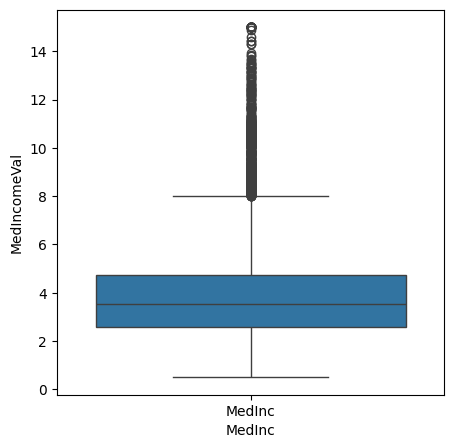

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
sns.boxplot([df_new['MedInc']])
plt.xlabel("MedInc")
plt.ylabel("MedIncomeVal")
plt.show()